# VQ-VAE Tokenizer Evaluation

Protein / Ligand VQ-VAE の学習後の定量的性能評価ノートブック。

**評価項目:**
1. 再構成誤差 (MSE) — 全体 & 次元別
2. Codebook 利用率 & Perplexity
3. Original vs Reconstructed の散布図
4. Codebook 使用頻度の分布
5. 潜在空間の可視化 (t-SNE)

In [34]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import CrossDockedConfig, VQVAETrainingConfig
from src.data.descriptors import ComplexDescriptorDataModule
from src.model.vqvae_module import VQVAEModule

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load checkpoint and data

In [35]:
# --- Checkpoint path (edit here) ---
# Best checkpoint is typically the one with lowest val/protein_recon.
# List available checkpoints:
ckpt_dir = project_root / "checkpoints"
if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.rglob("*.ckpt"))
    for p in ckpts:
        print(p.relative_to(project_root))
else:
    print("No checkpoints/ directory found. Check wandb run directory.")
    ckpts = sorted(project_root.rglob("*.ckpt"))
    for p in ckpts[-5:]:
        print(p.relative_to(project_root))

checkpoints/vqvae-epoch=02-val/protein_recon=0.7866.ckpt
checkpoints/vqvae-epoch=03-val/protein_recon=0.6128.ckpt
checkpoints/vqvae-epoch=04-val/protein_recon=0.4670.ckpt


In [36]:
# Load the best checkpoint (pick the last one = lowest val loss)
# CKPT_PATH = "~/git/pocket-conditioned-ligand-gen/pocket-ligand-vqvae/hfdu662j/checkpoints/vqvae-epoch=77-val/protein_recon=0.0642.ckpt"  # Edit if needed
CKPT_PATH = "/home/sakano/git/pocket-conditioned-ligand-gen/pocket-ligand-vqvae/zkixkowu/checkpoints/vqvae-epoch=93-val/protein_recon=0.2562.ckpt"
print(f"Loading: {CKPT_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
module = VQVAEModule.load_from_checkpoint(str(CKPT_PATH), map_location=device)
module.eval()
module.to(device)

protein_vqvae = module.protein_vqvae
ligand_vqvae = module.ligand_vqvae
print(f"Device: {device}")

Loading: /home/sakano/git/pocket-conditioned-ligand-gen/pocket-ligand-vqvae/zkixkowu/checkpoints/vqvae-epoch=93-val/protein_recon=0.2562.ckpt
Device: cuda


In [37]:
# Load cached descriptors and prepare validation split
config = VQVAETrainingConfig()
data_config = CrossDockedConfig(data_dir=project_root / "data")
dm = ComplexDescriptorDataModule(config, data_config)
dm.setup()

protein_val = dm.protein_val.to(device)
ligand_val = dm.ligand_val.to(device)

# Also load normalization stats for de-normalization
norm_stats = torch.load(
    project_root / "data" / "descriptor_cache" / "normalization_stats.pt",
    weights_only=True,
)
print(f"Protein val: {protein_val.shape}")
print(f"Ligand val:  {ligand_val.shape}")

Protein val: torch.Size([4719527, 9])
Ligand val:  torch.Size([4660095, 4])


In [38]:
# Run inference on validation set
@torch.no_grad()
def run_vqvae(model, data, batch_size=4096):
    """Run VQ-VAE on data in batches, return reconstructed, indices, and latents."""
    all_recon, all_indices, all_z = [], [], []
    for i in range(0, len(data), batch_size):
        batch = data[i : i + batch_size]
        z = model.encoder(batch)
        quantized, indices, _ = model.codebook(z)
        recon = model.decoder(quantized)
        all_recon.append(recon)
        all_indices.append(indices)
        all_z.append(z)
    return torch.cat(all_recon), torch.cat(all_indices), torch.cat(all_z)


prot_recon, prot_indices, prot_z = run_vqvae(protein_vqvae, protein_val)
lig_recon, lig_indices, lig_z = run_vqvae(ligand_vqvae, ligand_val)

print("Inference done.")

Inference done.


## 2. Reconstruction Error (MSE)

正規化空間と元スケールの両方で再構成誤差を評価する。

In [39]:
def compute_mse_metrics(original, reconstructed, name, norm_mean, norm_std):
    """Compute MSE in both normalized and original scale."""
    orig_np = original.cpu().numpy()
    recon_np = reconstructed.cpu().numpy()

    # Normalized space
    mse_norm = np.mean((orig_np - recon_np) ** 2)
    per_dim_mse_norm = np.mean((orig_np - recon_np) ** 2, axis=0)

    # De-normalize to original scale
    mean_np = norm_mean.numpy()
    std_np = norm_std.numpy()
    orig_denorm = orig_np * std_np + mean_np
    recon_denorm = recon_np * std_np + mean_np
    mse_orig = np.mean((orig_denorm - recon_denorm) ** 2)
    per_dim_mse_orig = np.mean((orig_denorm - recon_denorm) ** 2, axis=0)

    print(f"=== {name} VQ-VAE ===")
    print(f"  Overall MSE (normalized):  {mse_norm:.6f}")
    print(f"  Overall MSE (original):    {mse_orig:.6f}")
    print(f"  Overall RMSE (original):   {np.sqrt(mse_orig):.6f}")
    print()

    return {
        "mse_norm": mse_norm,
        "per_dim_mse_norm": per_dim_mse_norm,
        "mse_orig": mse_orig,
        "per_dim_mse_orig": per_dim_mse_orig,
        "orig_denorm": orig_denorm,
        "recon_denorm": recon_denorm,
    }


prot_metrics = compute_mse_metrics(
    protein_val,
    prot_recon,
    "Protein",
    norm_stats["protein_mean"],
    norm_stats["protein_std"],
)
lig_metrics = compute_mse_metrics(
    ligand_val,
    lig_recon,
    "Ligand",
    norm_stats["ligand_mean"],
    norm_stats["ligand_std"],
)

=== Protein VQ-VAE ===
  Overall MSE (normalized):  0.256225
  Overall MSE (original):    2.564172
  Overall RMSE (original):   1.601303

=== Ligand VQ-VAE ===
  Overall MSE (normalized):  0.057504
  Overall MSE (original):    0.039592
  Overall RMSE (original):   0.198977



### 2.1 Per-dimension MSE

Protein: dim 0–2 = CA position, dim 3–5 = N-CA offset, dim 6–8 = C-CA offset (canonical frame)
Ligand: dim 0 = bond length, dim 1 = bond angle, dim 2–3 = sin/cos dihedral

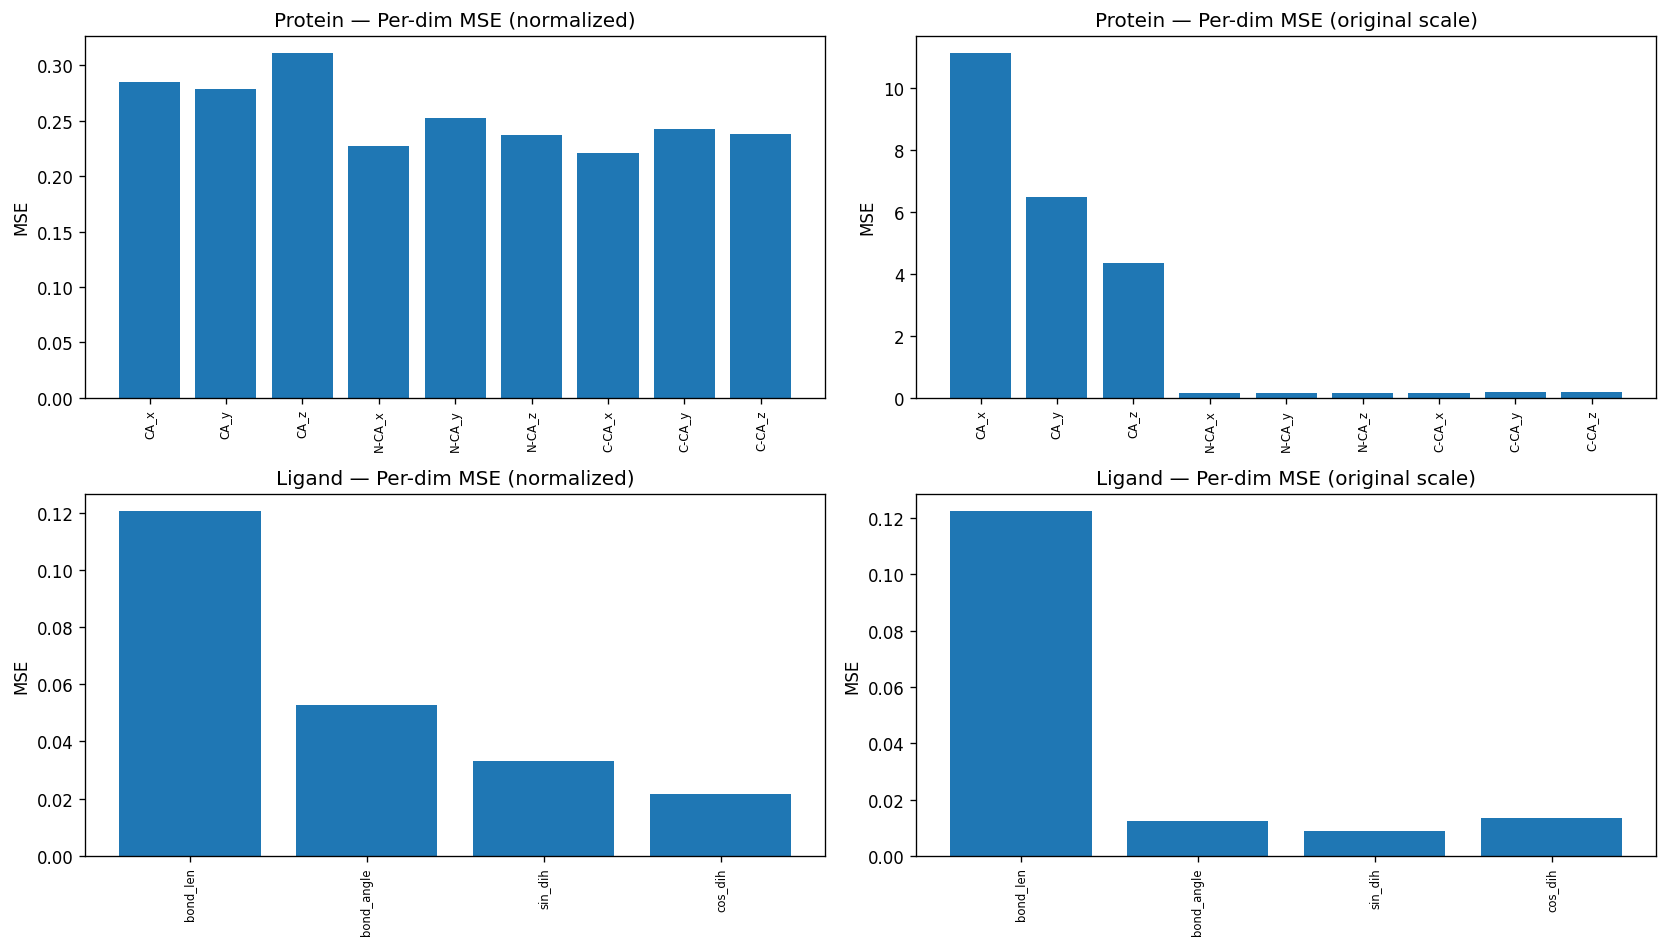

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Protein — normalized
prot_dim_labels = ["CA_x", "CA_y", "CA_z", "N-CA_x", "N-CA_y", "N-CA_z", "C-CA_x", "C-CA_y", "C-CA_z"]
axes[0, 0].bar(range(9), prot_metrics["per_dim_mse_norm"])
axes[0, 0].set_xticks(range(9), prot_dim_labels, rotation=90, fontsize=7)
axes[0, 0].set_title("Protein — Per-dim MSE (normalized)")
axes[0, 0].set_ylabel("MSE")

# Protein — original scale
axes[0, 1].bar(range(9), prot_metrics["per_dim_mse_orig"])
axes[0, 1].set_xticks(range(9), prot_dim_labels, rotation=90, fontsize=7)
axes[0, 1].set_title("Protein — Per-dim MSE (original scale)")
axes[0, 1].set_ylabel("MSE")

# Ligand — normalized
lig_dim_labels = ["bond_len", "bond_angle", "sin_dih", "cos_dih"]
axes[1, 0].bar(range(4), lig_metrics["per_dim_mse_norm"])
axes[1, 0].set_xticks(range(4), lig_dim_labels, rotation=90, fontsize=7)
axes[1, 0].set_title("Ligand — Per-dim MSE (normalized)")
axes[1, 0].set_ylabel("MSE")

# Ligand — original scale
axes[1, 1].bar(range(4), lig_metrics["per_dim_mse_orig"])
axes[1, 1].set_xticks(range(4), lig_dim_labels, rotation=90, fontsize=7)
axes[1, 1].set_title("Ligand — Per-dim MSE (original scale)")
axes[1, 1].set_ylabel("MSE")

fig.tight_layout()
plt.show()

## 3. Codebook Utilization & Perplexity

理想的なcodebookは全コードが均等に使われる。
- **Utilization**: 使用されたコード数 / 全コード数 (1.0が理想)
- **Perplexity**: exp(entropy)。均等利用時は codebook_size と一致

In [41]:
def codebook_stats(indices, codebook_size, name):
    """Compute and print codebook utilization metrics."""
    idx_np = indices.cpu().numpy()
    unique = np.unique(idx_np)
    utilization = len(unique) / codebook_size

    counts = np.bincount(idx_np, minlength=codebook_size).astype(float)
    probs = counts / counts.sum()
    probs_nonzero = probs[probs > 0]
    entropy = -np.sum(probs_nonzero * np.log(probs_nonzero))
    perplexity = np.exp(entropy)

    # Max perplexity = codebook_size (uniform distribution)
    max_perplexity = codebook_size
    normalized_perplexity = perplexity / max_perplexity

    print(f"=== {name} Codebook ===")
    print(f"  Codebook size:          {codebook_size}")
    print(f"  Active codes:           {len(unique)}")
    print(f"  Utilization:            {utilization:.4f}")
    print(f"  Perplexity:             {perplexity:.1f} / {max_perplexity}")
    print(f"  Normalized perplexity:  {normalized_perplexity:.4f}")
    print(f"  Dead codes:             {codebook_size - len(unique)}")
    print()
    return counts


prot_counts = codebook_stats(prot_indices, config.protein.codebook_size, "Protein")
lig_counts = codebook_stats(lig_indices, config.ligand.codebook_size, "Ligand")

=== Protein Codebook ===
  Codebook size:          512
  Active codes:           512
  Utilization:            1.0000
  Perplexity:             486.6 / 512
  Normalized perplexity:  0.9504
  Dead codes:             0

=== Ligand Codebook ===
  Codebook size:          256
  Active codes:           256
  Utilization:            1.0000
  Perplexity:             203.8 / 256
  Normalized perplexity:  0.7961
  Dead codes:             0



### 3.1 Codebook usage distribution

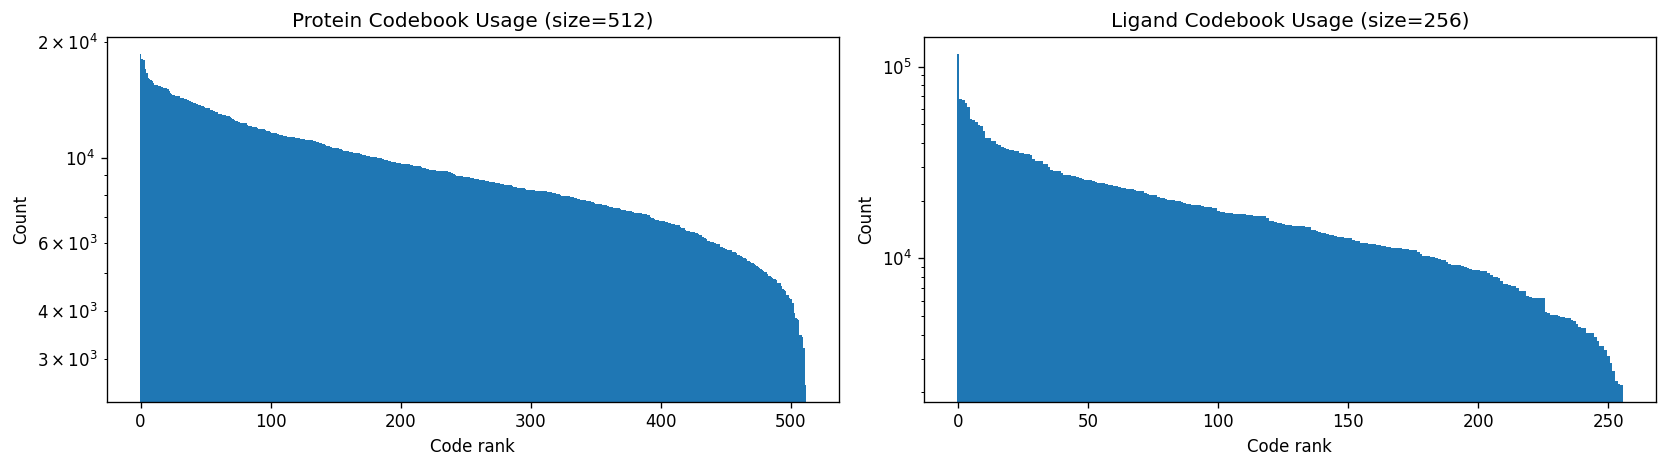

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Protein codebook usage — sorted descending
prot_sorted = np.sort(prot_counts)[::-1]
axes[0].bar(range(len(prot_sorted)), prot_sorted, width=1.0)
axes[0].set_xlabel("Code rank")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Protein Codebook Usage (size={config.protein.codebook_size})")
axes[0].set_yscale("log")

# Ligand codebook usage — sorted descending
lig_sorted = np.sort(lig_counts)[::-1]
axes[1].bar(range(len(lig_sorted)), lig_sorted, width=1.0)
axes[1].set_xlabel("Code rank")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Ligand Codebook Usage (size={config.ligand.codebook_size})")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()

## 4. Original vs Reconstructed scatter plots

各次元で元の値 vs 再構成値をプロットし、対角線からのずれを確認する。元スケールで表示。

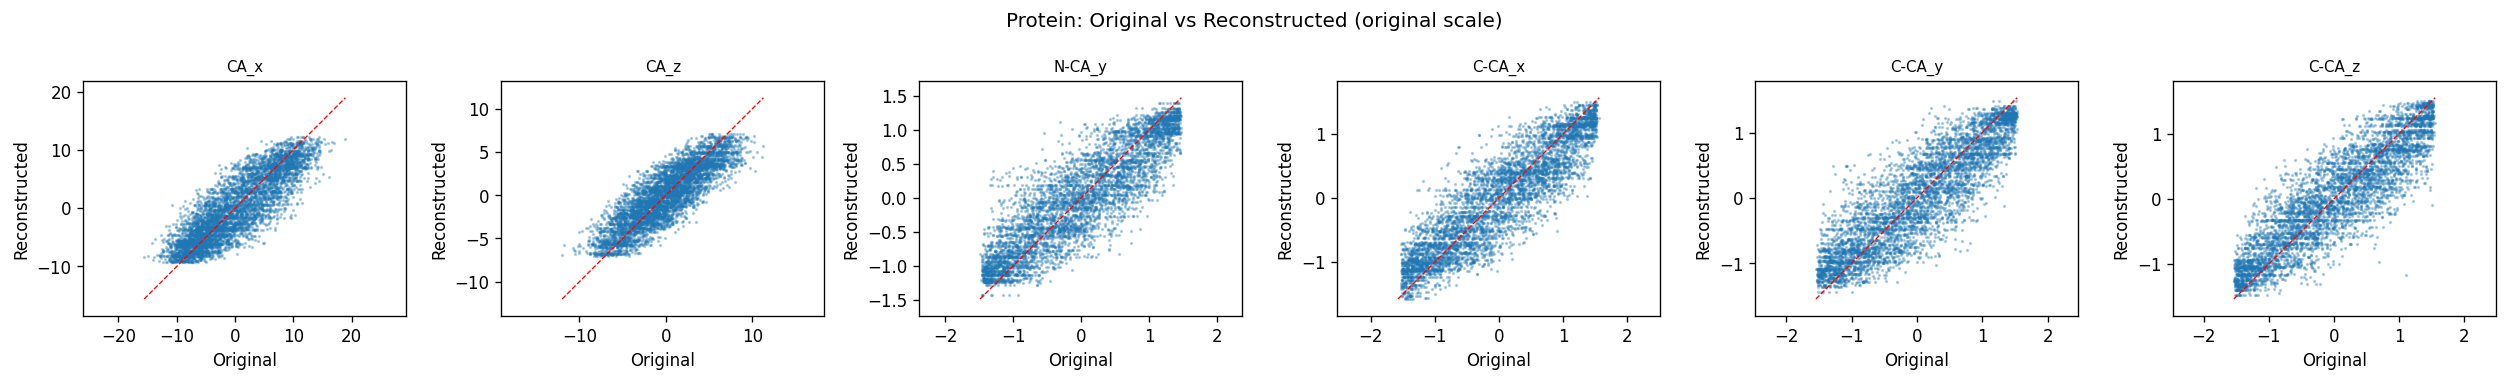

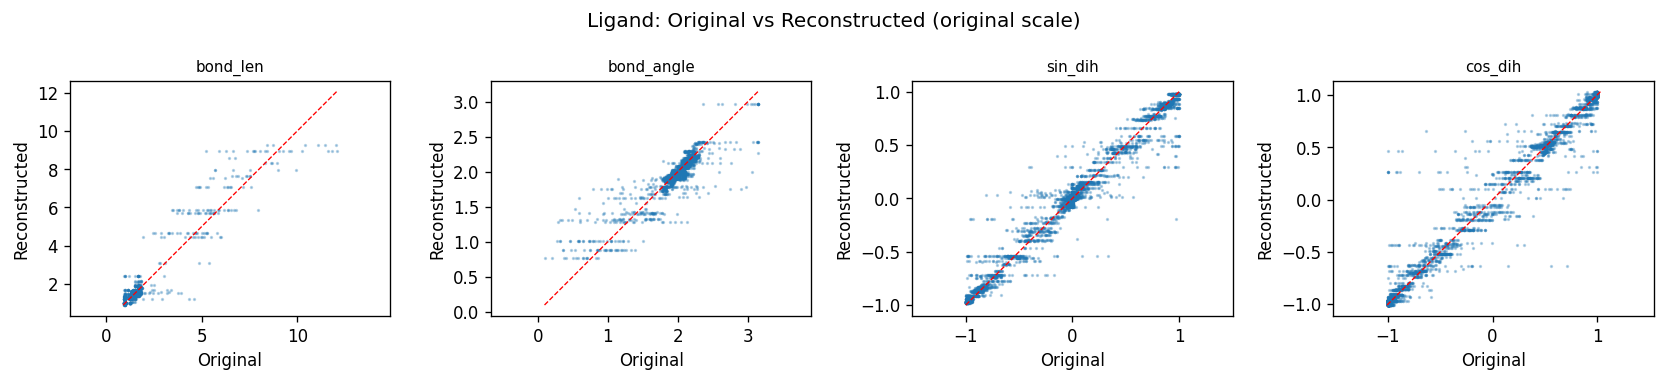

In [43]:
def scatter_orig_vs_recon(orig, recon, dim_labels, title, max_points=5000):
    """Scatter plot of original vs reconstructed for selected dimensions."""
    n_dims = orig.shape[1]
    # Select representative dims: first, middle, last, and a few key ones
    if n_dims <= 8:
        selected = list(range(n_dims))
    else:
        selected = [
            0,
            n_dims // 4,
            n_dims // 2,
            3 * n_dims // 4,
            n_dims - 2,
            n_dims - 1,
        ]

    n_plots = len(selected)
    fig, axes = plt.subplots(1, n_plots, figsize=(3.5 * n_plots, 3.2))
    if n_plots == 1:
        axes = [axes]

    # Subsample for plotting
    rng = np.random.default_rng(42)
    idx = rng.choice(len(orig), min(max_points, len(orig)), replace=False)

    for ax, dim in zip(axes, selected, strict=False):
        ax.scatter(orig[idx, dim], recon[idx, dim], s=1, alpha=0.3)
        lo = min(orig[idx, dim].min(), recon[idx, dim].min())
        hi = max(orig[idx, dim].max(), recon[idx, dim].max())
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=0.8)
        ax.set_xlabel("Original")
        ax.set_ylabel("Reconstructed")
        ax.set_title(dim_labels[dim], fontsize=9)
        ax.set_aspect("equal", adjustable="datalim")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


scatter_orig_vs_recon(
    prot_metrics["orig_denorm"],
    prot_metrics["recon_denorm"],
    prot_dim_labels,
    "Protein: Original vs Reconstructed (original scale)",
)
scatter_orig_vs_recon(
    lig_metrics["orig_denorm"],
    lig_metrics["recon_denorm"],
    lig_dim_labels,
    "Ligand: Original vs Reconstructed (original scale)",
)

## 5. Reconstruction error distribution

サンプルごとの再構成誤差の分布を確認し、外れ値の存在を把握する。

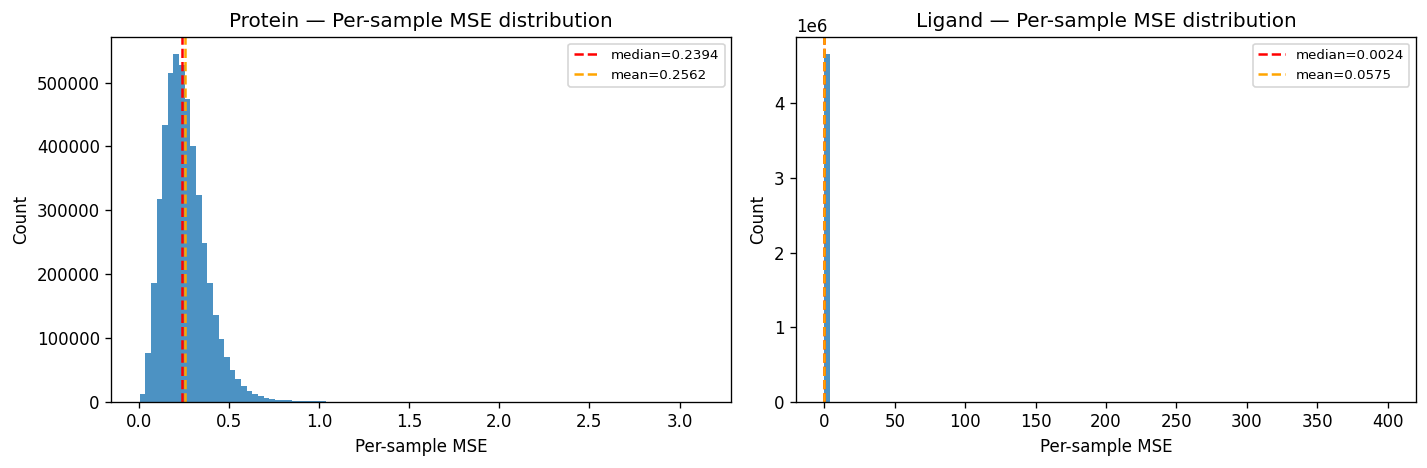

Protein per-sample MSE percentiles:
  P50: 0.239405
  P75: 0.321799
  P90: 0.411600
  P95: 0.475781
  P99: 0.626513

Ligand per-sample MSE percentiles:
  P50: 0.002417
  P75: 0.011470
  P90: 0.039017
  P95: 0.169842
  P99: 1.213430



In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-sample MSE (normalized space)
prot_per_sample = np.mean(
    (protein_val.cpu().numpy() - prot_recon.cpu().numpy()) ** 2,
    axis=1,
)
lig_per_sample = np.mean(
    (ligand_val.cpu().numpy() - lig_recon.cpu().numpy()) ** 2,
    axis=1,
)

axes[0].hist(prot_per_sample, bins=100, edgecolor="none", alpha=0.8)
axes[0].axvline(
    np.median(prot_per_sample),
    color="r",
    linestyle="--",
    label=f"median={np.median(prot_per_sample):.4f}",
)
axes[0].axvline(
    np.mean(prot_per_sample),
    color="orange",
    linestyle="--",
    label=f"mean={np.mean(prot_per_sample):.4f}",
)
axes[0].set_xlabel("Per-sample MSE")
axes[0].set_ylabel("Count")
axes[0].set_title("Protein — Per-sample MSE distribution")
axes[0].legend(fontsize=8)

axes[1].hist(lig_per_sample, bins=100, edgecolor="none", alpha=0.8)
axes[1].axvline(
    np.median(lig_per_sample),
    color="r",
    linestyle="--",
    label=f"median={np.median(lig_per_sample):.4f}",
)
axes[1].axvline(
    np.mean(lig_per_sample),
    color="orange",
    linestyle="--",
    label=f"mean={np.mean(lig_per_sample):.4f}",
)
axes[1].set_xlabel("Per-sample MSE")
axes[1].set_ylabel("Count")
axes[1].set_title("Ligand — Per-sample MSE distribution")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

# Percentile stats
for name, mse_arr in [("Protein", prot_per_sample), ("Ligand", lig_per_sample)]:
    print(f"{name} per-sample MSE percentiles:")
    for p in [50, 75, 90, 95, 99]:
        print(f"  P{p}: {np.percentile(mse_arr, p):.6f}")
    print()

## 5.5 3D Reconstruction RMSE (Å)

記述子空間での再構成誤差ではなく、実際の3次元座標に復元した上でのRMSEを評価する。

- **Protein**: backbone (N, CA, C) 座標の RMSE
- **Ligand**: 重原子座標の RMSE

複数の複合体をサンプリングし、VQ-VAE の encode → decode → 記述子逆変換 → 3D座標 のパイプライン全体の精度を確認する。

Evaluated 1000 complexes

Protein backbone RMSE (Å):
  Mean:   2.7044
  Median: 2.6980
  Std:    0.2763

Ligand heavy-atom RMSE (Å):
  Mean:   2.7376
  Median: 2.3929
  Std:    1.5328


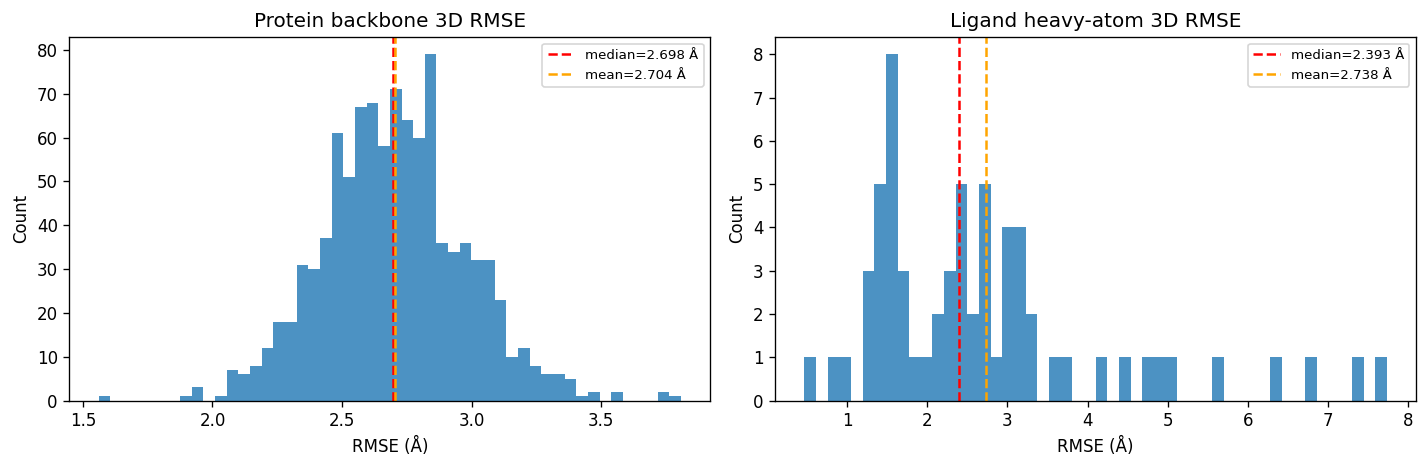

In [45]:
from src.config import PocketExtractionConfig
from src.data.descriptors import _parse_types_file
from src.tokenizers.ligand import LigandDescriptor, parse_sdf
from src.tokenizers.protein import PocketDescriptor, extract_pocket

pocket_config = PocketExtractionConfig()
protein_desc_calc = PocketDescriptor()
ligand_desc_calc = LigandDescriptor()

types_file = project_root / "data" / "types" / "cdonly_it2_tt_v1.3_0_train0.types"
pairs = _parse_types_file(types_file)
crossdocked_dir = project_root / "data" / "CrossDocked2020"

prot_mean = norm_stats["protein_mean"].to(device)
prot_std = norm_stats["protein_std"].to(device)
lig_mean = norm_stats["ligand_mean"].to(device)
lig_std = norm_stats["ligand_std"].to(device)

N_SAMPLES = 200
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(pairs), size=min(N_SAMPLES * 5, len(pairs)), replace=False)

prot_rmse_list = []
lig_rmse_list = []
n_done = 0

for idx in sample_indices:
    if n_done >= N_SAMPLES:
        break
    rec_rel, lig_rel = pairs[idx]
    rec_path = crossdocked_dir / rec_rel
    lig_path = crossdocked_dir / lig_rel
    if not rec_path.exists() or not lig_path.exists():
        continue

    try:
        # --- Original coordinates ---
        molecules = parse_sdf(lig_path)
        if not molecules:
            continue
        mol = molecules[0]
        lig_coords_orig = np.array(
            [(a[1], a[2], a[3]) for a in mol["atoms"] if a[0] != "H"],
            dtype=np.float32,
        )
        pocket_result = extract_pocket(rec_path, lig_coords_orig, pocket_config)
        if pocket_result is None:
            continue
        backbone_coords_orig, _seq = pocket_result

        # --- Protein round-trip ---
        prot_desc, prot_meta = protein_desc_calc.compute(backbone_coords_orig)
        pocket_frame = (prot_meta["centroid"], prot_meta["rotation"])
        prot_t = torch.from_numpy(prot_desc).to(device)
        prot_norm = (prot_t - prot_mean) / prot_std
        with torch.no_grad():
            z = protein_vqvae.encoder(prot_norm)
            q, _, _ = protein_vqvae.codebook(z)
            prot_recon_norm = protein_vqvae.decoder(q)
        prot_recon_desc = (prot_recon_norm * prot_std + prot_mean).cpu().numpy()
        backbone_recon = PocketDescriptor.descriptor_to_backbone_coords(
            prot_recon_desc, prot_meta,
        )
        prot_rmse = np.sqrt(
            np.mean((backbone_coords_orig - backbone_recon) ** 2)
        )
        prot_rmse_list.append(prot_rmse)

        # --- Ligand round-trip ---
        lig_desc, elements, lig_meta = ligand_desc_calc.compute(
            mol["atoms"], mol["bonds"], pocket_frame=pocket_frame,
        )
        if len(lig_desc) == 0:
            continue
        lig_t = torch.from_numpy(lig_desc).to(device)
        lig_norm = (lig_t - lig_mean) / lig_std
        with torch.no_grad():
            z = ligand_vqvae.encoder(lig_norm)
            q, _, _ = ligand_vqvae.codebook(z)
            lig_recon_norm = ligand_vqvae.decoder(q)
        lig_recon_desc = (lig_recon_norm * lig_std + lig_mean).cpu().numpy()
        lig_coords_recon = LigandDescriptor.descriptor_to_coords(
            lig_recon_desc, lig_meta, pocket_frame=pocket_frame,
        )
        # Original coords in canonical DFS order for comparison
        heavy_atoms = [a for a in mol["atoms"] if a[0] != "H"]
        lig_coords_orig_arr = np.array(
            [(a[1], a[2], a[3]) for a in heavy_atoms], dtype=np.float64,
        )
        lig_rmse = np.sqrt(
            np.mean((lig_coords_orig_arr - lig_coords_recon) ** 2)
        )
        lig_rmse_list.append(lig_rmse)
        n_done += 1

    except Exception:
        continue

prot_rmse_arr = np.array(prot_rmse_list)
lig_rmse_arr = np.array(lig_rmse_list)
print(f"Evaluated {len(prot_rmse_arr)} complexes")
print()
print("Protein backbone RMSE (Å):")
print(f"  Mean:   {prot_rmse_arr.mean():.4f}")
print(f"  Median: {np.median(prot_rmse_arr):.4f}")
print(f"  Std:    {prot_rmse_arr.std():.4f}")
print()
print("Ligand heavy-atom RMSE (Å):")
print(f"  Mean:   {lig_rmse_arr.mean():.4f}")
print(f"  Median: {np.median(lig_rmse_arr):.4f}")
print(f"  Std:    {lig_rmse_arr.std():.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prot_rmse_arr, bins=50, edgecolor="none", alpha=0.8)
axes[0].axvline(
    np.median(prot_rmse_arr), color="r", linestyle="--",
    label=f"median={np.median(prot_rmse_arr):.3f} Å",
)
axes[0].axvline(
    prot_rmse_arr.mean(), color="orange", linestyle="--",
    label=f"mean={prot_rmse_arr.mean():.3f} Å",
)
axes[0].set_xlabel("RMSE (Å)")
axes[0].set_ylabel("Count")
axes[0].set_title("Protein backbone 3D RMSE")
axes[0].legend(fontsize=8)

axes[1].hist(lig_rmse_arr, bins=50, edgecolor="none", alpha=0.8)
axes[1].axvline(
    np.median(lig_rmse_arr), color="r", linestyle="--",
    label=f"median={np.median(lig_rmse_arr):.3f} Å",
)
axes[1].axvline(
    lig_rmse_arr.mean(), color="orange", linestyle="--",
    label=f"mean={lig_rmse_arr.mean():.3f} Å",
)
axes[1].set_xlabel("RMSE (Å)")
axes[1].set_ylabel("Count")
axes[1].set_title("Ligand heavy-atom 3D RMSE")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 6. Latent space visualization (t-SNE)

Codebook ベクトルとエンコーダ出力を t-SNE で2次元に射影し、量子化の質を確認する。

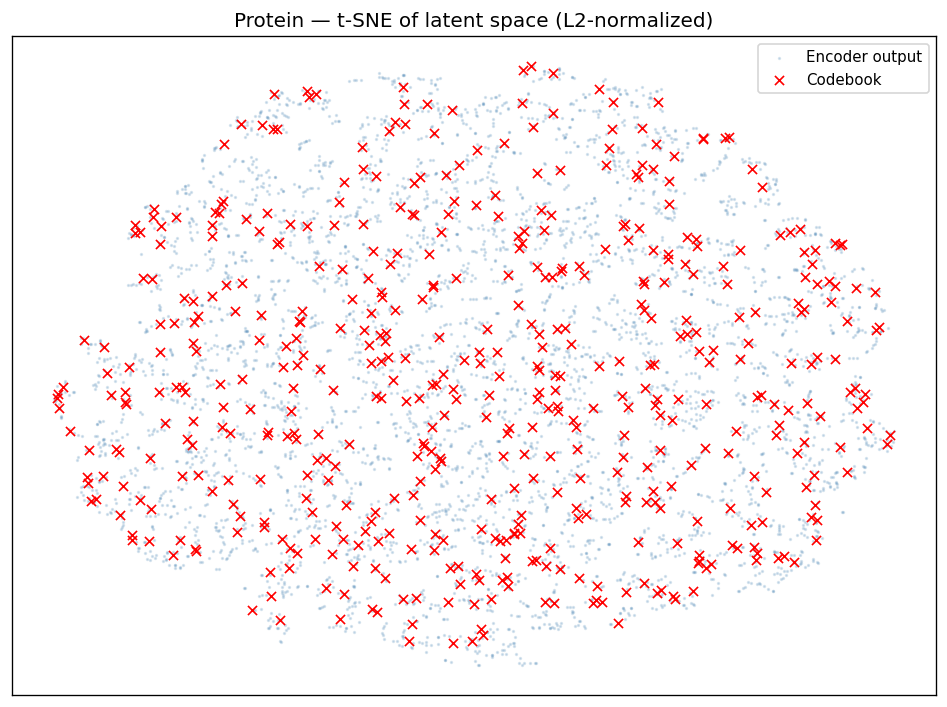

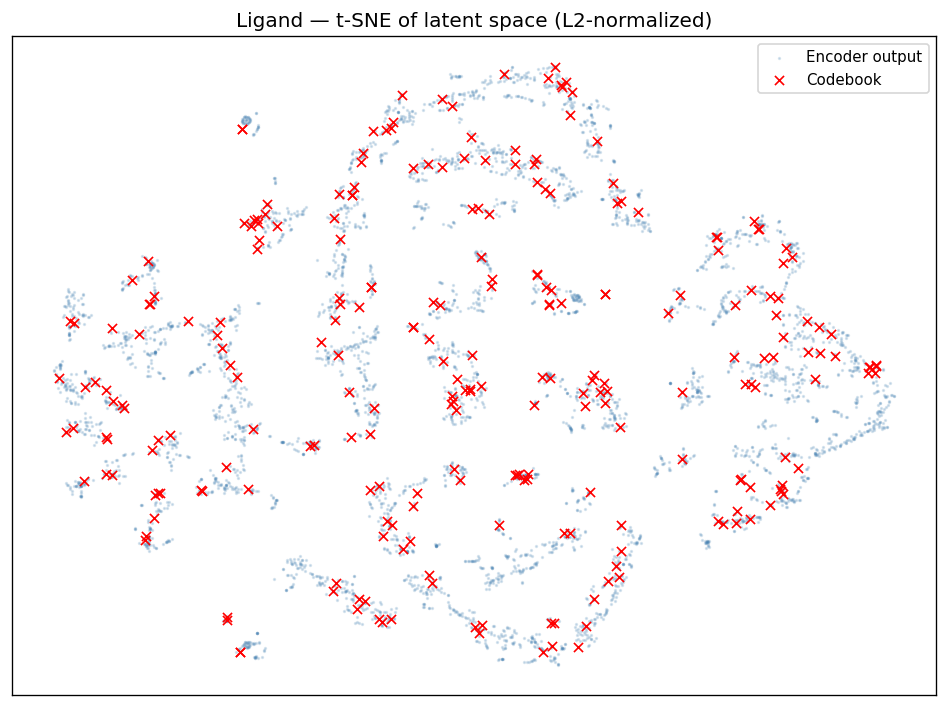

In [46]:
import torch.nn.functional as F
from sklearn.manifold import TSNE


def plot_latent_tsne(encoder_z, codebook, _codebook_size, name, n_samples=5000) -> None:
    """t-SNE visualization of encoder outputs and codebook vectors."""
    # L2 normalize (same as codebook forward)
    z_norm = F.normalize(encoder_z, p=2, dim=-1).cpu().numpy()
    cb_norm = F.normalize(codebook.embedding, p=2, dim=-1).cpu().detach().numpy()

    # Subsample encoder outputs
    rng = np.random.default_rng(42)
    idx = rng.choice(len(z_norm), min(n_samples, len(z_norm)), replace=False)
    z_sub = z_norm[idx]

    # Combine for t-SNE
    combined = np.vstack([z_sub, cb_norm])
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(combined) // 4))
    embedded = tsne.fit_transform(combined)

    z_emb = embedded[: len(z_sub)]
    cb_emb = embedded[len(z_sub) :]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        z_emb[:, 0], z_emb[:, 1], s=1, alpha=0.2, c="steelblue", label="Encoder output"
    )
    ax.scatter(
        cb_emb[:, 0],
        cb_emb[:, 1],
        s=30,
        c="red",
        marker="x",
        linewidths=1,
        label="Codebook",
    )
    ax.set_title(f"{name} — t-SNE of latent space (L2-normalized)")
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.tight_layout()
    plt.show()


plot_latent_tsne(
    prot_z, protein_vqvae.codebook, config.protein.codebook_size, "Protein"
)
plot_latent_tsne(lig_z, ligand_vqvae.codebook, config.ligand.codebook_size, "Ligand")

## 7. Summary table

In [47]:
import pandas as pd

prot_idx_np = prot_indices.cpu().numpy()
lig_idx_np = lig_indices.cpu().numpy()

prot_probs = np.bincount(prot_idx_np, minlength=config.protein.codebook_size).astype(
    float
)
prot_probs = prot_probs / prot_probs.sum()
prot_probs_nz = prot_probs[prot_probs > 0]
prot_ppl = np.exp(-np.sum(prot_probs_nz * np.log(prot_probs_nz)))

lig_probs = np.bincount(lig_idx_np, minlength=config.ligand.codebook_size).astype(float)
lig_probs = lig_probs / lig_probs.sum()
lig_probs_nz = lig_probs[lig_probs > 0]
lig_ppl = np.exp(-np.sum(lig_probs_nz * np.log(lig_probs_nz)))

summary = pd.DataFrame(
    {
        "Metric": [
            "Codebook size",
            "Latent dim",
            "Val MSE (normalized)",
            "Val MSE (original scale)",
            "Val RMSE (original scale)",
            "Active codes",
            "Utilization",
            "Perplexity",
            "Perplexity (normalized)",
            "Learnable scale (exp(log_scale))",
        ],
        "Protein": [
            config.protein.codebook_size,
            config.protein.latent_dim,
            f"{prot_metrics['mse_norm']:.6f}",
            f"{prot_metrics['mse_orig']:.6f}",
            f"{np.sqrt(prot_metrics['mse_orig']):.6f}",
            len(np.unique(prot_idx_np)),
            f"{len(np.unique(prot_idx_np)) / config.protein.codebook_size:.4f}",
            f"{prot_ppl:.1f}",
            f"{prot_ppl / config.protein.codebook_size:.4f}",
            f"{protein_vqvae.codebook.log_scale.exp().item():.4f}",
        ],
        "Ligand": [
            config.ligand.codebook_size,
            config.ligand.latent_dim,
            f"{lig_metrics['mse_norm']:.6f}",
            f"{lig_metrics['mse_orig']:.6f}",
            f"{np.sqrt(lig_metrics['mse_orig']):.6f}",
            len(np.unique(lig_idx_np)),
            f"{len(np.unique(lig_idx_np)) / config.ligand.codebook_size:.4f}",
            f"{lig_ppl:.1f}",
            f"{lig_ppl / config.ligand.codebook_size:.4f}",
            f"{ligand_vqvae.codebook.log_scale.exp().item():.4f}",
        ],
    }
)

summary

,Metric,Protein,Ligand
0,Codebook size,512,256
1,Latent dim,8,4
2,Val MSE (normalized),0.256225,0.057504
3,Val MSE (original scale),2.564172,0.039592
4,Val RMSE (original scale),1.601303,0.198977
5,Active codes,512,256
6,Utilization,1.0000,1.0000
7,Perplexity,486.6,203.8
8,Perplexity (normalized),0.9504,0.7961
9,Learnable scale (exp(log_scale)),1.6952,1.4393


## 8. 3D Structure & Token Sequence Visualization

CrossDocked2020 から実際の複合体を1つ取り出し、ポケット構造・リガンド構造を py3Dmol で表示するとともに、VQ-VAE によるトークン列を確認する。

In [48]:
import gzip
import re

import py3Dmol
from IPython.display import HTML
from IPython.display import display as ipy_display

from src.config import PocketExtractionConfig
from src.data.descriptors import _parse_types_file
from src.tokenizers.ligand import LigandDescriptor, parse_sdf
from src.tokenizers.protein import (
    PocketDescriptor,
    extract_full_sequence,
    extract_pocket,
)
from src.tokenizers.sequence import TokenSequenceAssembler

# --- Pick a sample complex ---
types_file = project_root / "data" / "types" / "cdonly_it2_tt_v1.3_0_train0.types"
pairs = _parse_types_file(types_file)
crossdocked_dir = project_root / "data" / "CrossDocked2020"

# Try a few pairs until we find one that works
SAMPLE_IDX = 0
for _try_idx in range(min(20, len(pairs))):
    rec_rel, lig_rel = pairs[SAMPLE_IDX + _try_idx]
    rec_path = crossdocked_dir / rec_rel
    lig_path = crossdocked_dir / lig_rel
    if rec_path.exists() and lig_path.exists():
        SAMPLE_IDX += _try_idx
        break

print(f"Sample #{SAMPLE_IDX}")
print(f"  Receptor: {rec_rel}")
print(f"  Ligand:   {lig_rel}")

Sample #0
  Receptor: 1433B_HUMAN_1_240_pep_0/2bq0_A_rec.pdb
  Ligand:   1433B_HUMAN_1_240_pep_0/2bq0_A_rec_5f74_amp_lig_tt_docked.sdf.gz


In [49]:
# --- Extract pocket and compute token sequence ---
pocket_config = PocketExtractionConfig()
molecules = parse_sdf(lig_path)
mol = molecules[0]
lig_coords = np.array([(a[1], a[2], a[3]) for a in mol["atoms"] if a[0] != "H"], dtype=np.float32)

pocket_result = extract_pocket(rec_path, lig_coords, pocket_config)
backbone_coords, pocket_seq = pocket_result
full_seq = extract_full_sequence(rec_path)

# Compute protein descriptors → VQ-VAE tokens
protein_desc_calc = PocketDescriptor()
prot_desc_raw, _prot_meta = protein_desc_calc.compute(backbone_coords)

prot_t = torch.from_numpy(prot_desc_raw).to(device)
prot_t = (prot_t - norm_stats["protein_mean"].to(device)) / norm_stats["protein_std"].to(device)

with torch.no_grad():
    prot_code_indices = protein_vqvae.encode(prot_t).cpu().tolist()

pocket_tokens = [f"{aa}_{code}" for aa, code in zip(pocket_seq, prot_code_indices, strict=True)]

# Compute ligand descriptors → VQ-VAE tokens
ligand_desc_calc = LigandDescriptor()
lig_desc_raw, elements, _ = ligand_desc_calc.compute(mol["atoms"], mol["bonds"])

lig_t = torch.from_numpy(lig_desc_raw).to(device)
lig_t = (lig_t - norm_stats["ligand_mean"].to(device)) / norm_stats["ligand_std"].to(device)

with torch.no_grad():
    lig_code_indices = ligand_vqvae.encode(lig_t).cpu().tolist()

ligand_tokens = [f"{elem}_{code}" for elem, code in zip(elements, lig_code_indices, strict=True)]

# Assemble full token sequence
assembler = TokenSequenceAssembler()
token_sequence = assembler.assemble(pocket_tokens, full_seq, ligand_tokens)

print(f"Pocket residues: {len(pocket_seq)}")
print(f"Ligand atoms:    {len(elements)}")
print(f"Full sequence:   {len(full_seq)} AAs")

Pocket residues: 24
Ligand atoms:    29
Full sequence:   230 AAs


### 8.1 3D Viewer: Pocket (cartoon) + Ligand (stick)

- **タンパク質**: 全体を薄い cartoon で表示し、ポケット残基をハイライト
- **リガンド**: stick 表示（元素ごとに色分け）

In [50]:
# --- Identify pocket residue IDs for highlighting ---
from Bio.PDB import PDBParser as _PDBParser

from src.tokenizers.protein import AA_3TO1, BACKBONE_ATOMS

_parser = _PDBParser(QUIET=True)
_structure = _parser.get_structure("rec", str(rec_path))
_model = _structure[0]

pocket_residue_ids = []  # (chain_id, resi)
for chain in _model:
    for residue in chain:
        if residue.get_resname() not in AA_3TO1:
            continue
        if not all(a in residue for a in BACKBONE_ATOMS):
            continue
        ca = residue["CA"].get_vector().get_array()
        if np.min(np.linalg.norm(lig_coords - ca, axis=1)) <= pocket_config.distance_cutoff:
            pocket_residue_ids.append((chain.id, residue.get_id()[1]))

# Read raw PDB text
pdb_block = rec_path.read_text()

# Read raw SDF text (decompress .sdf.gz)
with gzip.open(str(lig_path), "rt") as f:
    sdf_full = f.read()
# Take only the first molecule (up to first $$$$)
sdf_block = sdf_full.split("$$$$")[0] + "$$$$\n"

# --- Build py3Dmol viewer ---
view = py3Dmol.view(width=800, height=500)

# Add protein
view.addModel(pdb_block, "pdb")
# Light cartoon for whole protein
view.setStyle({"model": 0}, {"cartoon": {"color": "white", "opacity": 0.3}})
# Highlight pocket residues
pocket_resi = [r[1] for r in pocket_residue_ids]
view.setStyle(
    {"model": 0, "resi": pocket_resi},
    {"cartoon": {"color": "skyblue", "opacity": 0.9}, "stick": {"color": "skyblue", "radius": 0.1}},
)

# Add ligand
view.addModel(sdf_block, "sdf")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "default", "radius": 0.2}})

view.zoomTo({"model": 1})  # Focus on ligand
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 8.2 Token Sequence

上記の複合体をトークナイズした結果。各セクションを色分けして表示する。
- <span style="color:#4a90d9">**青**: ポケット構造トークン `<p>AA_code ...</p>`</span>
- <span style="color:#2ecc71">**緑**: タンパク質配列 `<s>MKTII...</s>`</span>
- <span style="color:#e74c3c">**赤**: リガンド構造トークン `<l>elem_code ...</l>`</span>

In [51]:
# --- Render token sequence with color-coded sections ---
def render_token_sequence(seq: str) -> str:
    """Render token sequence as color-coded HTML."""
    m = re.match(r"<p>(.*?)</p><s>(.*?)</s><l>(.*?)</l>", seq, re.DOTALL)
    if not m:
        return seq
    pocket_str, seq_str, ligand_str = m.groups()

    pocket_toks = pocket_str.split()
    ligand_toks = ligand_str.split()

    # Wrap each token in a styled span
    def _tok_span(tok, color):
        return f'<span style="background:{color};padding:1px 3px;margin:1px;border-radius:3px;font-size:12px">{tok}</span>'

    pocket_html = " ".join(_tok_span(t, "#d6eaf8") for t in pocket_toks)
    ligand_html = " ".join(_tok_span(t, "#fadbd8") for t in ligand_toks)

    # Truncate sequence if very long
    seq_display = seq_str if len(seq_str) <= 80 else seq_str[:40] + "..." + seq_str[-40:]
    seq_html = f'<span style="background:#d5f5e3;padding:1px 3px;border-radius:3px;font-size:12px;word-break:break-all">{seq_display}</span>'

    return (
        '<div style="font-family:monospace;line-height:2.2">'
        f'<b style="color:#4a90d9">&lt;p&gt;</b> {pocket_html} <b style="color:#4a90d9">&lt;/p&gt;</b><br>'
        f'<b style="color:#2ecc71">&lt;s&gt;</b> {seq_html} <b style="color:#2ecc71">&lt;/s&gt;</b><br>'
        f'<b style="color:#e74c3c">&lt;l&gt;</b> {ligand_html} <b style="color:#e74c3c">&lt;/l&gt;</b>'
        "</div>"
    )


ipy_display(HTML(render_token_sequence(token_sequence)))
print(f"\nTotal tokens: {len(pocket_tokens)} (pocket) + {len(full_seq)} (seq) + {len(ligand_tokens)} (ligand) = {len(pocket_tokens) + len(full_seq) + len(ligand_tokens)}")


Total tokens: 24 (pocket) + 230 (seq) + 29 (ligand) = 283


### 8.3 Codebook Index Distribution per Atom/Residue

この複合体におけるトークン（codebook index）の分布を確認する。

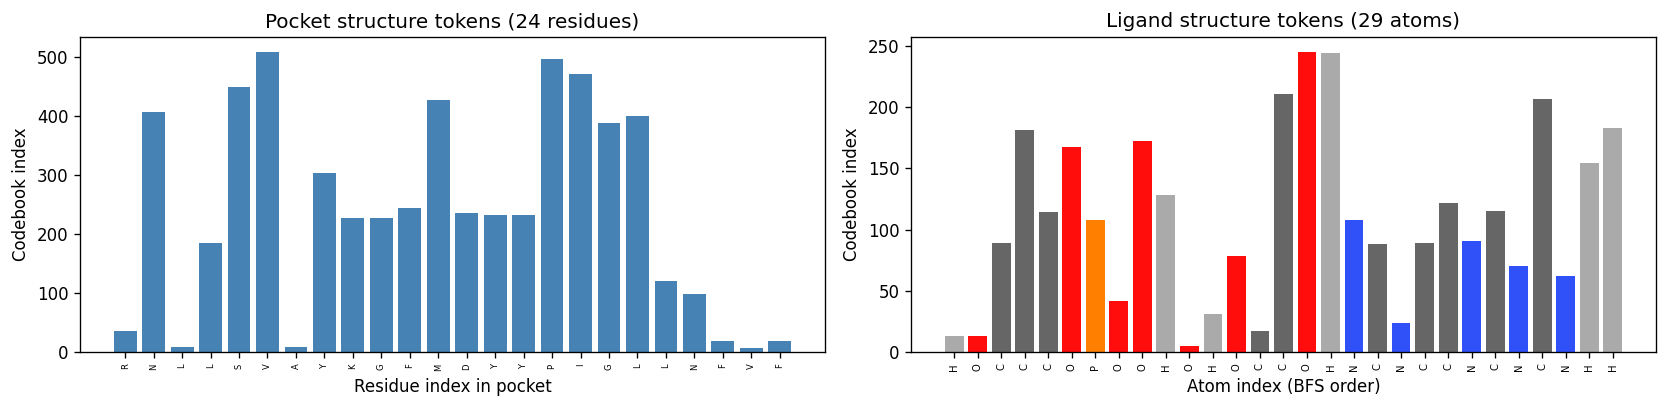

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Protein pocket: codebook index per residue
axes[0].bar(range(len(prot_code_indices)), prot_code_indices, width=0.8, color="steelblue")
axes[0].set_xlabel("Residue index in pocket")
axes[0].set_ylabel("Codebook index")
axes[0].set_title(f"Pocket structure tokens ({len(prot_code_indices)} residues)")
# Annotate amino acids on x-axis
axes[0].set_xticks(range(len(pocket_seq)))
axes[0].set_xticklabels(list(pocket_seq), fontsize=5, rotation=90)

# Ligand: codebook index per atom
colors = {"C": "#666666", "N": "#3050F8", "O": "#FF0D0D", "S": "#FFFF30", "F": "#90E050", "Cl": "#1FF01F", "Br": "#A62929", "P": "#FF8000"}
bar_colors = [colors.get(e, "#AAAAAA") for e in elements]
axes[1].bar(range(len(lig_code_indices)), lig_code_indices, width=0.8, color=bar_colors)
axes[1].set_xlabel("Atom index (BFS order)")
axes[1].set_ylabel("Codebook index")
axes[1].set_title(f"Ligand structure tokens ({len(lig_code_indices)} atoms)")
axes[1].set_xticks(range(len(elements)))
axes[1].set_xticklabels(elements, fontsize=6, rotation=90)

fig.tight_layout()
plt.show()